In [1]:
## 实例一
import requests #用于发送HTTP请求
from bs4 import BeautifulSoup #用于解析HTML文档
headers={'User-Agent':'Mozilla/5.0(Windows NT6.1; Win64;x64)AppleWebKit/537.36(KHTML,likeGecko) Chrome/99.0.4844.74 Safari/537.36'}#设置请求头
url="https://www.douban.com/tag/%E5%B0%8F%E8%AF%B4/?focus=book"# 定义URL
r=requests.get(url,headers=headers)
html=r.text #获取文本内容
soup=BeautifulSoup(html,"html.parser") #使用parser实现文本解析
book_div=soup.find(attrs={"id":"book"})#查找id为book的div元素
book_a=book_div.findAll(attrs={"class":"title"})# 书名
for book1 in book_a:
    print(book1.string)
book_b=book_div.findAll(attrs={"class":"desc"}) # 书信息
for book2 in book_b:
    print(book2.string.strip('\n'))

骆驼祥子
黄金时代
人间草木
苏菲的世界
阿Q正传
梦里花落知多少
回归故里
步履不停
动物园
        老舍 / 人民文学出版社 / 1962-10-1 / 12.00元
      
        王小波 / 花城出版社 / 1999-3 / 19.00元
      
        汪曾祺 / 江苏文艺出版社 / 2005-01 / 20.00元
      
        [挪威] 乔斯坦·贾德 / 萧宝森 / 作家出版社 / 2017-8 / 38.00元
      
        鲁迅 著 / 丰子恺 绘 / 上海书店出版社 / 2003-7 / 14.50元
      
        三毛 / 北京十月文艺出版社 / 2007-6 / 28.00元
      
        [法]迪迪埃·埃里蓬 / 王献 / 上海文化出版社 / 2020-7 / 48.00元
      
        [日] 是枝裕和 / 郑有杰 / 北京联合出版公司 / 2017-5 / 36.80元
      
        [日] 乙一 / 张筱森 / 人民文学出版社 / 2016-8-1 / 49.80
      


In [2]:
## 实例二
import requests
from bs4 import BeautifulSoup
from openpyxl import Workbook
headers={'User-Agent':'Mozilla/5.0(Windows NT6.1; Win64;x64)AppleWebKit/537.36(KHTML,likeGecko) Chrome/99.0.4844.74 Safari/537.36'}#设置请求头
url="https://www.douban.com/tag/%E5%B0%8F%E8%AF%B4/?focus=book"# 定义URL
r=requests.get(url,headers=headers)
html=r.text
soup=BeautifulSoup(html,"html.parser")
book_div=soup.find(attrs={"id":"book"})
book_a=book_div.findAll(attrs={"class":"title"})
book_b=book_div.findAll(attrs={"class":"desc"})
a,b,bb,cc,dd=[],[],[],[],[]
for book1 in book_a:
    a.append(book1.string)
for book1 in book_b:
    b.append(book1.string)
for i in range(len(b)):
    b[i]=b[i].strip('\n  ').split('/')
    for j in range(len(b[i])):
        b[i][j]=b[i][j].strip(' ')
for i in range(len(b)):
    bb.extend(b[i])
    cc.append({'书名':a[i]})
    if(len(bb)==6):
        dd.append({'书名':cc[0]["书名"],'作者':bb[0],'译者1':bb[1],'译者2':bb[2],'出版社':bb[3],'出版日期':bb[4],'价格':bb[5]})
    elif(len(bb)==5):
        dd.append({'书名':cc[0]["书名"],'作者':bb[0],'译者1':bb[1],'译者2':'','出版社':bb[2],'出版日期':bb[3],'价格':bb[4]})
    else:
        dd.append({'书名':cc[0]["书名"],'作者':bb[0],'译者1':'','译者2':'','出版社':bb[1],'出版日期':bb[2],'价格':bb[3]})

    bb.clear()
    cc.clear()

def save_excel(fin_result,tag_name,file_name):
    print("正在导出数据...")
    wb=Workbook()
    ws=wb.active
    ws.append(tag_name)
    for row in fin_result:
        ws.append(row)
    wb.save('{}.csv'.format(file_name))
            
def get_info(page,tag):
    ret=[]
    for item in page:
        row=[]
        for page_tag in tag:
            row.append(item[page_tag])
        ret.append(row)
    return ret
tag_name=['书名','作者','译者1','译者2','出版社','出版日期','价格']
fin_result=get_info(dd,tag_name)
file_name=input("爬取完成，输入要保存数据的文件名：")
save_excel(fin_result,tag_name,file_name)
print("数据爬取并保存成功！")

爬取完成，输入要保存数据的文件名：pachong_510
正在导出数据...
数据爬取并保存成功！


In [46]:
## 思考一
import requests
from bs4 import BeautifulSoup
from openpyxl import Workbook
with open("C:\\Users\\86185\\Desktop\\专业课\\大三上\\人工智能大数据\\实验\\实验四\\实验四\\实验四\\unrate.htm",'r')as wb_data:
    soup=BeautifulSoup(wb_data,"html.parser")
    book_div=soup.find(attrs={"id":"unrate_4077"})
    a,b,dd=[],[],[]
    book_a=book_div.findAll(attrs={"class":"xl644077"})
    book_b=book_div.findAll(attrs={"class":"xl654077"})
    for book1 in book_a:
        a.append(book1.string)
    for book2 in book_b:
        b.append(book2.string)
    for i in range(len(b)):
        dd.append({'DATE':a[i],'VALUE':b[i]})
def save_excel(fin_result,tag_name,file_name):
    print("正在导出数据...")
    wb=Workbook()
    ws=wb.active
    ws.append(tag_name)
    for row in fin_result:
        ws.append(row)
    wb.save('{}.csv'.format(file_name))
def get_info(page,tag):
    ret=[]
    for item in page:
        row=[]
        for page_tag in tag:
            row.append(item[page_tag])
        ret.append(row)
    return ret
tag_name=['DATE','VALUE']
fin_result=get_info(dd,tag_name)
file_name=input("爬取完成，输入要保存数据的文件名：")
save_excel(fin_result,tag_name,file_name)
print("数据爬取并保存成功！")

爬取完成，输入要保存数据的文件名：SYL_510
正在导出数据...
数据爬取并保存成功！


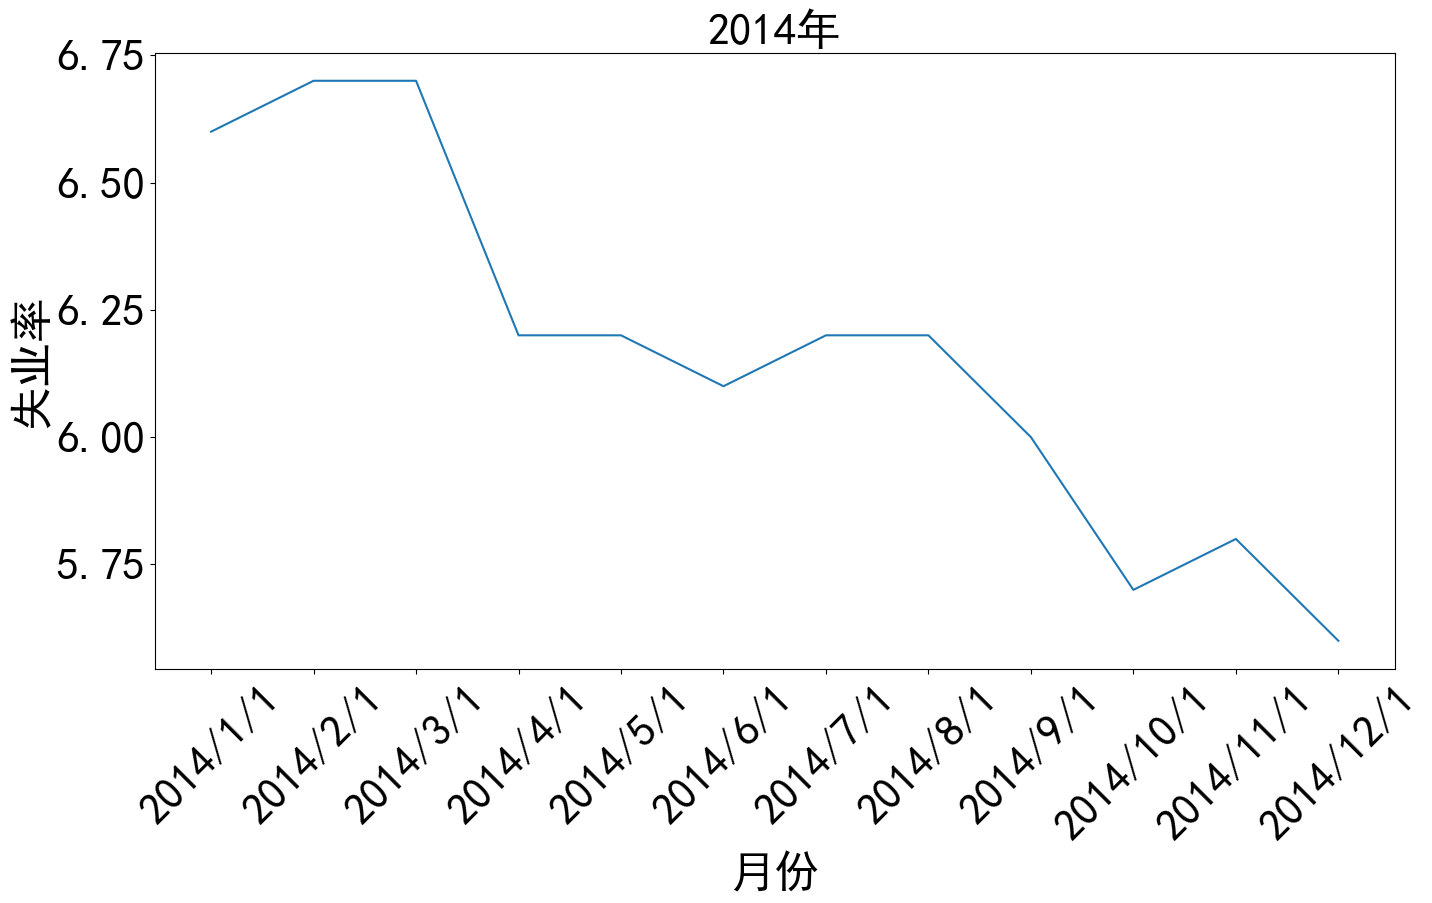

In [3]:
## 作图
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
plt.figure(figsize=(16,8))
unrate=pd.read_excel("C:\\Users\\86185\\Desktop\\专业课\\大三上\\人工智能大数据\\实验\\实验四\\SYL_510.csv")
first_twelve=unrate[0:12]
plt.plot(first_twelve['DATE'],first_twelve['VALUE'])
plt.xticks(rotation=45)
plt.xlabel('月份',fontsize=32)
plt.ylabel('失业率',fontsize=32)
plt.title('2014年',fontsize=32)
plt.tick_params(labelsize=32)
plt.show()